In [34]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Load the updated dataset
df = pd.read_csv("data/updated_counts_severity_dataset.csv")

# Ensure the target column has no missing values
df = df.dropna(subset=["explicit"])

# Fill missing lyrics with empty strings
df["lyrics"].fillna("", inplace=True)

# Define feature sets
category_count_features = [
    "violence_content_count", "drug_content_count", "hate_speech_content_count", 
    "profanity_content_count", "mental_slurs_content_count", "religious_slurs_content_count", 
    "racial_slurs_content_count", "sexual_content_content_count"
]
category_severity_features = [
    "violence_avg_severity", "drug_avg_severity", "hate_speech_avg_severity", 
    "profanity_avg_severity", "mental_slurs_avg_severity", "religious_slurs_avg_severity", 
    "racial_slurs_avg_severity", "sexual_content_avg_severity"
]
numerical_features = [
    "acousticness", "danceability", "energy", "instrumentalness", 
    "loudness", "speechiness", "tempo", "valence"
]

# Combine features for modeling
all_features = category_severity_features + numerical_features
X_numerical = df[all_features]
y = df["explicit"]  # Target variable


C:\Users\ziyue\AppData\Local\Temp\ipykernel_19512\247774105.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["lyrics"].fillna("", inplace=True)


In [23]:
# Convert lyrics to TF-IDF features
tfidf = TfidfVectorizer(max_features=5000)  # Use the top 5000 most important words
X_text = tfidf.fit_transform(df["lyrics"])

# Normalize numerical features
imputer = SimpleImputer(strategy="mean")
scaler = MinMaxScaler()

X_numerical_imputed = imputer.fit_transform(X_numerical)
X_numerical_scaled = scaler.fit_transform(X_numerical_imputed)

# Combine text and numerical features
X_combined = hstack([X_text, X_numerical_scaled])


C:\Users\ziyue\AppData\Local\Temp\ipykernel_19512\70020892.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_ratios_df, x="Explicit Ratio", y="Category", palette="rocket")


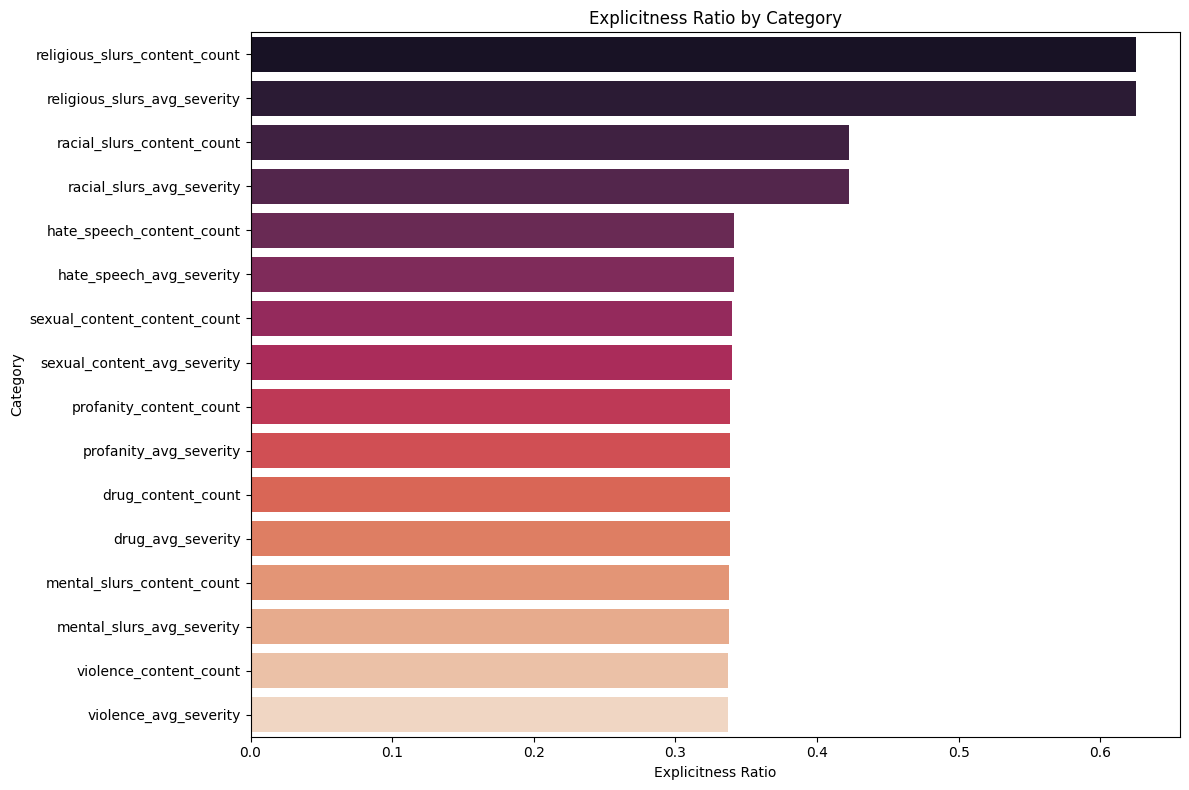

In [4]:
# Analyze explicitness ratios for count and severity features
category_ratios = {}
for category in category_count_features + category_severity_features:
    ratio = df[df[category] > 0]["explicit"].mean()
    category_ratios[category] = ratio

# Convert to DataFrame for visualization
category_ratios_df = pd.DataFrame({
    "Category": category_ratios.keys(),
    "Explicit Ratio": category_ratios.values()
}).sort_values(by="Explicit Ratio", ascending=False)

# Plot explicitness ratios
plt.figure(figsize=(12, 8))
sns.barplot(data=category_ratios_df, x="Explicit Ratio", y="Category", palette="rocket")
plt.title("Explicitness Ratio by Category")
plt.xlabel("Explicitness Ratio")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


Naive Bayes Accuracy: 0.7112264763140818
Classification Report:
               precision    recall  f1-score   support

         0.0       0.70      0.98      0.82      1027
         1.0       0.84      0.17      0.28       514

    accuracy                           0.71      1541
   macro avg       0.77      0.57      0.55      1541
weighted avg       0.75      0.71      0.64      1541



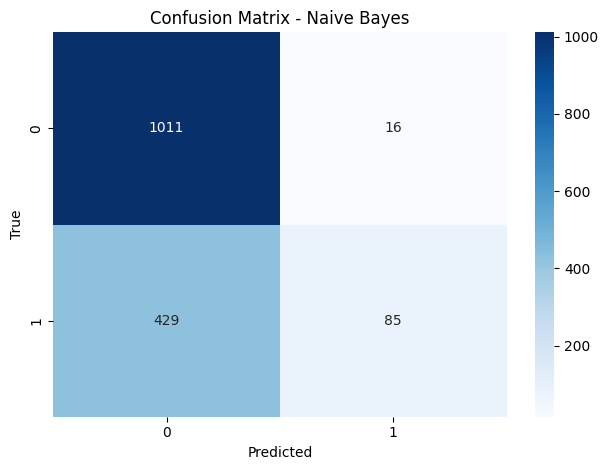

Naive Bayes class distribution: 0.0    1440
1.0     101
Name: count, dtype: int64


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y)

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Evaluate Naive Bayes
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

# Plot confusion matrix
nb_cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(nb_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Class distribution
print("Naive Bayes class distribution:", pd.Series(y_pred_nb).value_counts())


KNN Accuracy: 0.81829980532122
Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1027
         1.0       0.76      0.67      0.71       514

    accuracy                           0.82      1541
   macro avg       0.80      0.78      0.79      1541
weighted avg       0.82      0.82      0.82      1541



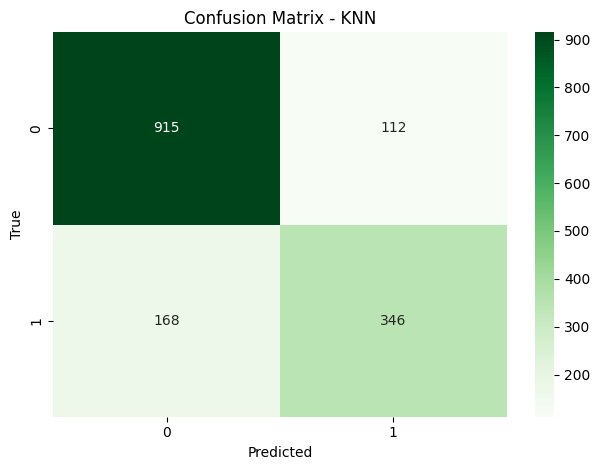

KNN class distribution: 0.0    1083
1.0     458
Name: count, dtype: int64


In [6]:
# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Evaluate KNN
y_pred_knn = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

# Plot confusion matrix
knn_cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Class distribution
print("KNN class distribution:", pd.Series(y_pred_knn).value_counts())


C:\Users\ziyue\anaconda3\envs\6120\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5


C:\Users\ziyue\anaconda3\envs\6120\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.6715 - loss: 0.6248

C:\Users\ziyue\anaconda3\envs\6120\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


193/193 ━━━━━━━━━━━━━━━━━━━━ 60s 282ms/step - accuracy: 0.6716 - loss: 0.6246 - val_accuracy: 0.7216 - val_loss: 0.5250
Epoch 2/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 56s 290ms/step - accuracy: 0.7509 - loss: 0.5142 - val_accuracy: 0.8222 - val_loss: 0.4515
Epoch 3/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 59s 304ms/step - accuracy: 0.7941 - loss: 0.4443 - val_accuracy: 0.8209 - val_loss: 0.4088
Epoch 4/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 58s 298ms/step - accuracy: 0.8273 - loss: 0.3845 - val_accuracy: 0.8196 - val_loss: 0.4029
Epoch 5/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 59s 306ms/step - accuracy: 0.8388 - loss: 0.3676 - val_accuracy: 0.8209 - val_loss: 0.4018
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.8178 - loss: 0.4165
LSTM Accuracy: 0.8209


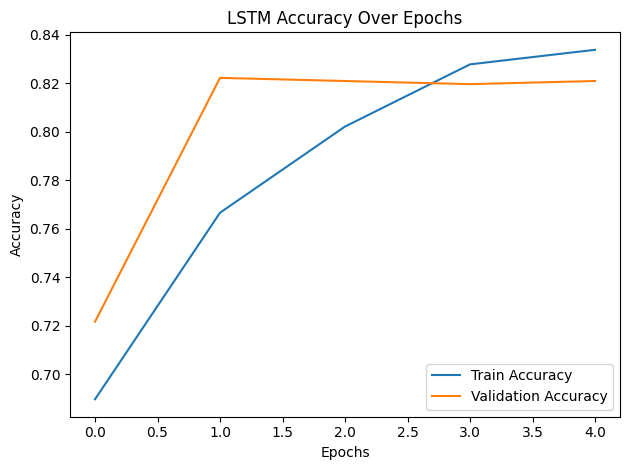

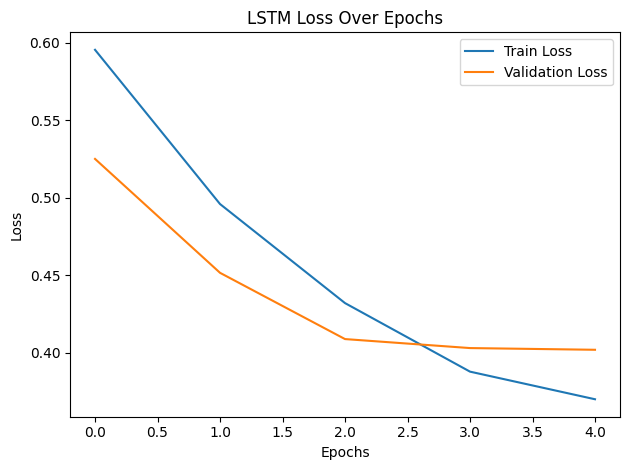

C:\Users\ziyue\anaconda3\envs\6120\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step


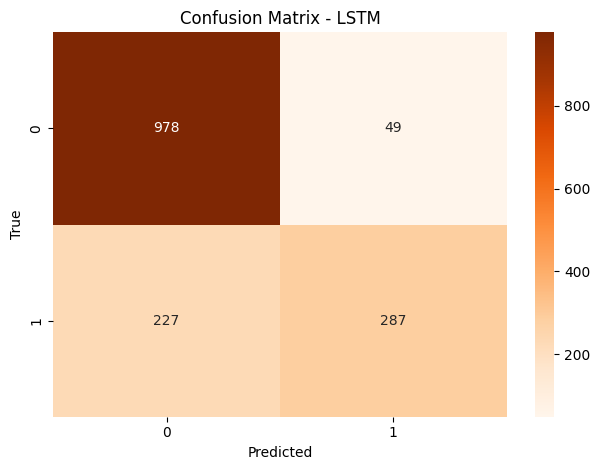

LSTM class distribution: 0    1205
1     336
Name: count, dtype: int64


In [7]:
# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df["lyrics"])
X_text_seq = tokenizer.texts_to_sequences(df["lyrics"])
X_text_pad = pad_sequences(X_text_seq, maxlen=300)

# Train-test split
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text_pad, X_numerical_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define LSTM model
input_text = Input(shape=(300,))
input_num = Input(shape=(X_train_num.shape[1],))

text_embedding = Embedding(input_dim=5000, output_dim=64, input_length=300)(input_text)
text_lstm = LSTM(128)(text_embedding)

combined = Concatenate()([text_lstm, input_num])
dense = Dense(64, activation="relu")(combined)
dropout = Dropout(0.5)(dense)
output = Dense(1, activation="sigmoid")(dropout)

model = Model(inputs=[input_text, input_num], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train LSTM
history = model.fit(
    [X_train_text, X_train_num], y_train, epochs=5, batch_size=32, 
    validation_data=([X_test_text, X_test_num], y_test)
)

# Evaluate LSTM
loss, accuracy = model.evaluate([X_test_text, X_test_num], y_test)
print(f"LSTM Accuracy: {accuracy:.4f}")

# Plot training metrics
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# LSTM confusion matrix
lstm_pred = (model.predict([X_test_text, X_test_num]) > 0.5).astype(int)
lstm_cm = confusion_matrix(y_test, lstm_pred)
sns.heatmap(lstm_cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Class distribution
print("LSTM class distribution:", pd.Series(lstm_pred.flatten()).value_counts())


In [24]:
# Load the updated dataset
df = pd.read_csv("data/updated_counts_severity_dataset.csv")

# Ensure the target column has no missing values
df = df.dropna(subset=["explicit", "lyrics"])
#df = df.dropna(how='all')

# Fill missing lyrics with empty strings
#df["lyrics"].dropna()

df = df.reset_index(drop=True)

# Define feature sets
category_count_features = [
    "violence_content_count", "drug_content_count", "hate_speech_content_count", 
    "profanity_content_count", "mental_slurs_content_count", "religious_slurs_content_count", 
    "racial_slurs_content_count", "sexual_content_content_count"
]
category_severity_features = [
    "violence_avg_severity", "drug_avg_severity", "hate_speech_avg_severity", 
    "profanity_avg_severity", "mental_slurs_avg_severity", "religious_slurs_avg_severity", 
    "racial_slurs_avg_severity", "sexual_content_avg_severity"
]
numerical_features = [
    "acousticness", "danceability", "energy", "instrumentalness", 
    "loudness", "speechiness", "tempo", "valence"
]

# Combine features for modeling
all_features = category_severity_features + numerical_features
X_numerical = df[all_features]
y = df["explicit"]  # Target variable


In [25]:
# Convert lyrics to TF-IDF features
#tfidf = TfidfVectorizer(max_features=5000)  # Use the top 5000 most important words
#X_text = tfidf.fit_transform(df["lyrics"])

# Normalize numerical features
imputer = SimpleImputer(strategy="mean")
#scaler = MinMaxScaler()

X_numerical_imputed = imputer.fit_transform(X_numerical)
#X_numerical_scaled = scaler.fit_transform(X_numerical_imputed)

# Combine text and numerical features
#X_combined = hstack([X_text, X_numerical_scaled])


In [26]:
import torch
from transformers import BertModel
from transformers import BertTokenizer

text = list(df['lyrics'])
#X_numerical_scaled, y = torch.tensor(X_numerical_scaled), torch.tensor(y)
y = torch.tensor(y)
text_b_train, text_b_test, X_train_b_num, X_test_b_num, y_b_train, y_b_test = train_test_split(text, X_numerical_imputed, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
class SongExplicitnessModel(torch.nn.Module):
    def __init__(self, transformer_model_name='bert-base-uncased', num_numerical_features=len(X_train_b_num[0])):
        super(SongExplicitnessModel, self).__init__()
        self.transformer = BertModel.from_pretrained(transformer_model_name)
        self.fc_text = torch.nn.Linear(self.transformer.config.hidden_size, 256)  # Text-to-hidden layer
        self.fc_numerical = torch.nn.Linear(len(X_train_b_num[0]), 64)  # Numerical-to-hidden layer
        self.fc_combined = torch.nn.Linear(256 + 64, 1)  # Combined layer
        self.sigmoid = torch.nn.Sigmoid()  # For binary classification (explicit or not)

    def forward(self, input_ids, attention_mask, numerical_features):
        # Pass text through the BERT model
        text_output = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        text_embedding = text_output.last_hidden_state.mean(dim=1)  # Mean pooling to get a fixed-size embedding

        #print("Text Embedding Shape:", text_embedding.shape)
        text_embedding = self.fc_text(text_embedding)

        
        # Process numerical features
        numerical_embedding = self.fc_numerical(numerical_features)
        #print("Numerical Embedding Shape:", numerical_embedding.shape)

        # Combine the text and numerical features
        combined = torch.cat((text_embedding, numerical_embedding), dim=1)
        combined_output = self.fc_combined(combined)
        # print("Combined Shape:", combined.shape)
        
        # Output layer
        output = self.sigmoid(combined_output)
        # During forward pass
        return output

In [28]:
# Initialize the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Example sentences
texts = list(text_b_train)

# Tokenize the inputs and generate the attention_mask
'''encoded_inputs = tokenizer(
    texts,                         # Input texts
    padding=True,                  # Pad shorter sequences to match the longest
    truncation=True,               # Truncate longer sequences to max_length
    max_length=128,                 # Set a max length for padding/truncation
    return_tensors="pt"            # Return PyTorch tensors
)

# The resulting dictionary contains:
input_ids = encoded_inputs['input_ids']          # Token IDs for the sentences
attention_mask = encoded_inputs['attention_mask']  # Attention mask (1s and 0s)

print("Input IDs:\n", input_ids)
print("Attention Mask:\n", attention_mask)'''

'encoded_inputs = tokenizer(\n    texts,                         # Input texts\n    padding=True,                  # Pad shorter sequences to match the longest\n    truncation=True,               # Truncate longer sequences to max_length\n    max_length=128,                 # Set a max length for padding/truncation\n    return_tensors="pt"            # Return PyTorch tensors\n)\n\n# The resulting dictionary contains:\ninput_ids = encoded_inputs[\'input_ids\']          # Token IDs for the sentences\nattention_mask = encoded_inputs[\'attention_mask\']  # Attention mask (1s and 0s)\n\nprint("Input IDs:\n", input_ids)\nprint("Attention Mask:\n", attention_mask)'

In [29]:
from torch.utils.data import Dataset, DataLoader

class SongDataset(Dataset):
    def __init__(self, texts, numerical_features, labels, tokenizer, max_length=128):
        self.texts = texts
        self.numerical_features = numerical_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        numerical_feature = self.numerical_features[idx]
        label = self.labels[idx]

        tokenized = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )
        return (
            tokenized['input_ids'].squeeze(0),
            tokenized['attention_mask'].squeeze(0),
            torch.tensor(numerical_feature, dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32)
        )

dataset = SongDataset(text_b_train, X_train_b_num, y_b_train, tokenizer)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
test_dataset = SongDataset(text_b_test, X_test_b_num, y_b_test, tokenizer)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [30]:
from torch.optim import Adam

model = SongExplicitnessModel()
criterion = torch.nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification
optimizer = Adam(model.parameters(), lr=0.6e-4)

device = "cpu"
model.to(device)

SongExplicitnessModel(
  (transformer): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-

In [16]:
num_epochs = 3
losses = []
epochs = []
accuracies = []
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    correct_predictions = 0
    total_predictions = 0
    for input_ids, attention_mask, numerical_features, labels in dataloader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        numerical_features = numerical_features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, numerical_features)
        outputs= outputs.squeeze(-1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        predictions = torch.round(outputs)  # Example for binary classification
        #print(predictions, labels)
        correct_predictions += (predictions == labels).sum().item()
        total_predictions += labels.size(0)

    epoch_accuracy = correct_predictions / total_predictions
    accuracies.append(epoch_accuracy)
    print(f"Epoch {epoch + 1}/{num_epochs}, Accuracy: {epoch_accuracy}, Loss: {epoch_loss / len(dataloader):.4f}")
    epochs.append(epoch+1)
    losses.append(epoch_loss / len(dataloader))
    fpath = "transformer_model_checkpoint_{f}.pth".format(f=epoch)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        }, fpath)
torch.save(model, 'transformer_model.pth')

C:\Users\ziyue\AppData\Local\Temp\ipykernel_19512\1980449341.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(label, dtype=torch.float32)


torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([12, 1])
Epoch 1/3, Accuracy: 0.7956026058631922, Loss: 0.4778
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.Size([32, 1])
torch.

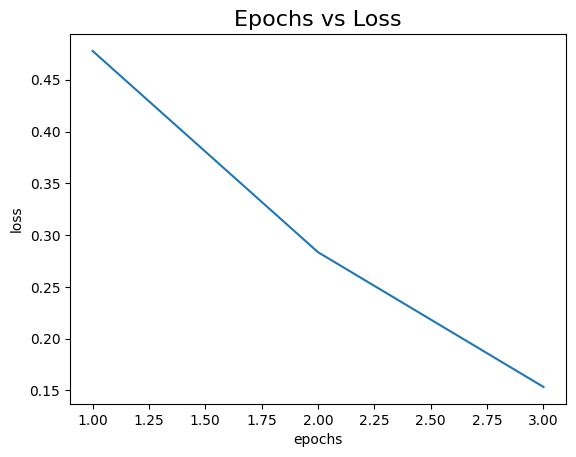

In [17]:
fig = plt.figure()
plt.title("Epochs vs Loss", fontsize=16)
plt.plot(epochs, losses)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()
fig.savefig("epochs_vs_loss.jpg")

In [31]:
model = torch.load("transformer_model.pth")
model.eval()

C:\Users\ziyue\AppData\Local\Temp\ipykernel_19512\7563663.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("transformer_model.pth")


SongExplicitnessModel(
  (transformer): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-

C:\Users\ziyue\AppData\Local\Temp\ipykernel_19512\1980449341.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(label, dtype=torch.float32)


Accuracy: 0.8896103896103896, Loss: 0.3611
Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.93      0.92       205
         1.0       0.86      0.81      0.83       103

    accuracy                           0.89       308
   macro avg       0.88      0.87      0.87       308
weighted avg       0.89      0.89      0.89       308



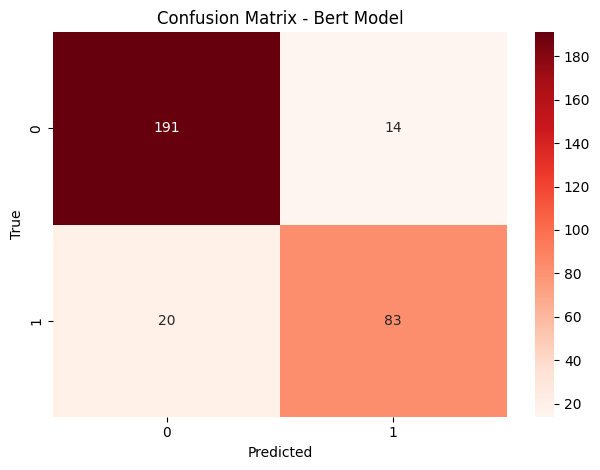

In [36]:
#model.eval()
#model.train()
epoch_loss = 0
correct_predictions = 0
total_predictions = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for input_ids, attention_mask, numerical_features, labels in test_dataloader:
        #passing to the model
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        numerical_features = numerical_features.to(device)
        labels = labels.to(device)

        outputs = model(input_ids, attention_mask, numerical_features)
        outputs= outputs.squeeze(-1)

        #compute loss
        loss = criterion(outputs, labels)
        epoch_loss += loss.item()

        predictions = torch.round(outputs)  # Example for binary classification
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        #print(predictions, labels)
        correct_predictions += (predictions == labels).sum().item()
        total_predictions += labels.size(0)
epoch_accuracy = correct_predictions / total_predictions
bert_cm = confusion_matrix(all_labels, all_preds)
print(f"Accuracy: {epoch_accuracy}, Loss: {epoch_loss / len(test_dataloader):.4f}")
print("Classification Report:\n", classification_report(all_labels, all_preds))
sns.heatmap(bert_cm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - Bert Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()    